In [1]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib and seaborn for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# LabelEncoder converts categorical text data into numbers
from sklearn.preprocessing import LabelEncoder

# Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load the dataset CSV file into a pandas dataframe
df = pd.read_csv("HR_comma_sep.csv")

# Display the first 5 rows of the dataset
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
# Display basic information about the dataset
# Shows number of rows, columns, data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
# Display statistical summary of numerical columns
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [5]:
# Check if there are any missing values in the dataset
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

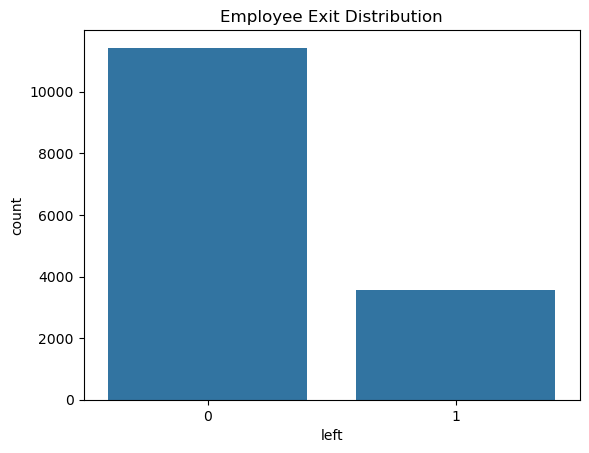

In [6]:
# Create a countplot to visualize how many employees stayed vs left
sns.countplot(x='left', data=df)

# Add a title to the graph
plt.title("Employee Exit Distribution")

# Display the plot
plt.show()

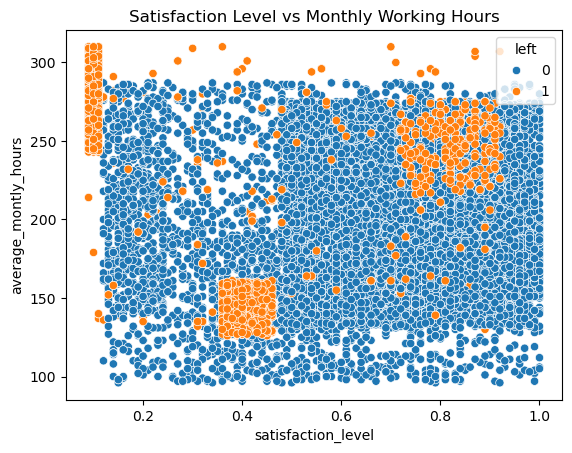

In [7]:
# Scatter plot to observe relationship between satisfaction and working hours
sns.scatterplot(x='satisfaction_level', y='average_montly_hours', hue='left', data=df)

# Add title
plt.title("Satisfaction Level vs Monthly Working Hours")

# Show plot
plt.show()

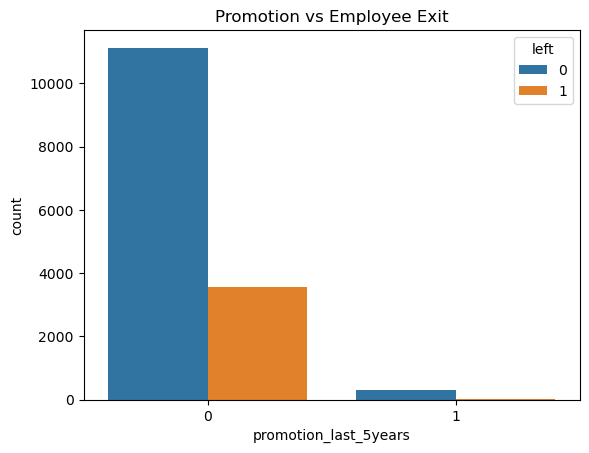

In [8]:
# Plot to check effect of promotions on employee attrition
sns.countplot(x='promotion_last_5years', hue='left', data=df)

# Add title
plt.title("Promotion vs Employee Exit")

# Display plot
plt.show()

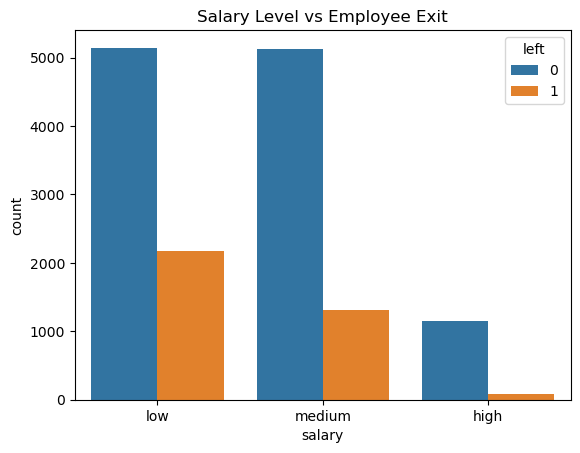

In [9]:
# Visualize how salary level affects employee attrition
sns.countplot(x='salary', hue='left', data=df)

# Add title
plt.title("Salary Level vs Employee Exit")

# Show the plot
plt.show()

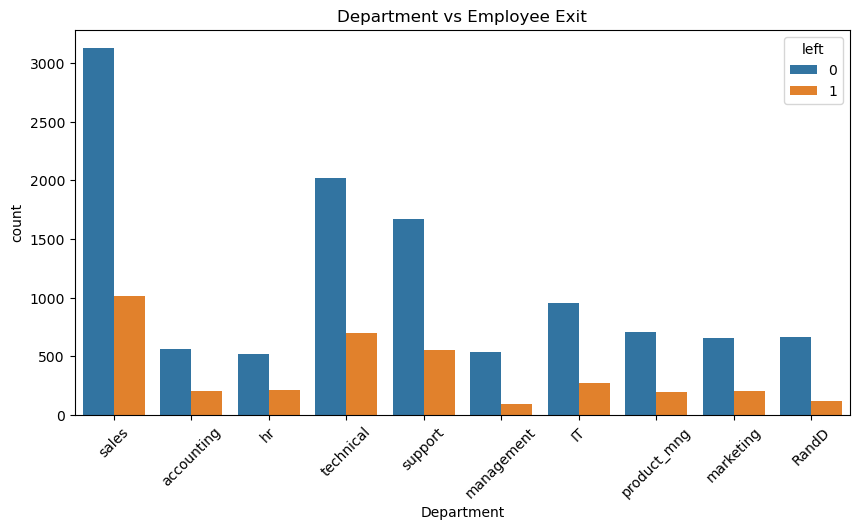

In [10]:
# Plot department-wise attrition
plt.figure(figsize=(10,5))

sns.countplot(x='Department', hue='left', data=df)

# Rotate department names for readability
plt.xticks(rotation=45)

plt.title("Department vs Employee Exit")

plt.show()

In [11]:
# Create LabelEncoder object
le = LabelEncoder()

# Convert Department column from text to numbers
df['Department'] = le.fit_transform(df['Department'])

# Convert salary column from text to numbers
df['salary'] = le.fit_transform(df['salary'])

In [12]:
# X contains all input features except the target column
X = df.drop('left', axis=1)

# y is the target variable (whether employee left)
y = df['left']

In [13]:
# Split dataset into training and testing sets
# 80% data used for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model using training data
lr_model.fit(X_train, y_train)

# Predict employee exit using test data
lr_predictions = lr_model.predict(X_test)

# Print accuracy of the model
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))

Logistic Regression Accuracy: 0.7583333333333333


In [15]:
# Create Decision Tree model
dt_model = DecisionTreeClassifier()

# Train the model
dt_model.fit(X_train, y_train)

# Predict results
dt_predictions = dt_model.predict(X_test)

# Print accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))

Decision Tree Accuracy: 0.976


In [16]:
# Create Random Forest model
rf_model = RandomForestClassifier()

# Train the model
rf_model.fit(X_train, y_train)

# Predict results
rf_predictions = rf_model.predict(X_test)

# Print accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))

Random Forest Accuracy: 0.9886666666666667


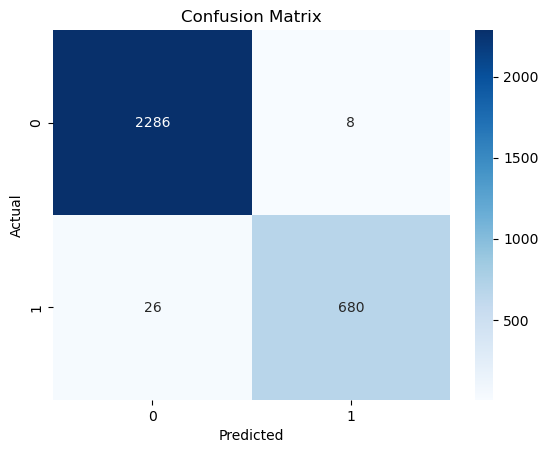

In [17]:
# Generate confusion matrix for Random Forest predictions
cm = confusion_matrix(y_test, rf_predictions)

# Visualize confusion matrix using heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [18]:
# Display precision, recall and F1-score
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2294
           1       0.99      0.96      0.98       706

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000

